In [3]:
import sys 
import os 
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from analysis_of_simulation_result import * 
from fitting import *
from plot_of_experiment_data import std_err
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7
colors_labial = ['#26ac39','#f39900']
colors_tarsal = ['#13739E','#952B7E']

In [11]:
# Load data 
from pathlib import Path
DATA_ROOT = Path("/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure4/PER_fitting_final/data")
Exp_Data_ROOT = DATA_ROOT/'Experiment_data_final'  
Simul_Data_ROOT = DATA_ROOT/'simulation_data_final'

DATASETS = {
    "tarsal_all": {
        "path": Exp_Data_ROOT / "tarsal_PER.xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
    "tarsal_TPN1": {
        "path": Exp_Data_ROOT / "atGRN_Kir2.1.xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
    "tarsal_atGRN": {
        "path": Exp_Data_ROOT / "Gr5a_Kir2.1.xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
    "labial_all": {
        "path": Exp_Data_ROOT / "labial_PER.xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
    "labial_L1L2": {
        "path": Exp_Data_ROOT / "Ir56b_Kir2.1(L1+L2).xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
    "labial_L3": {
        "path": Exp_Data_ROOT / "Gr5a-Ir56b_Kir2.1(L3).xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
}

experiment_data = {
    name: load_per_pair(
        excel_path=info["path"],
        sugar_sheet=info["sugar_sheet"],
        geosmin_sheet=info["geosmin_sheet"],
    )
    for name, info in DATASETS.items()
}



In [12]:
# Load simulation Data
from scipy.interpolate import RegularGridInterpolator
at_vals = np.arange(0, 201, 20)   # [0,20,...,200] → 11개
tp_vals = np.arange(0, 201, 20)   # 11개

Z_sim_tarsal = np.array(pd.read_parquet(Simul_Data_ROOT/'tarsal/tarsal_sugar.parquet'))
Z_sim_geo_tarsal = np.array(pd.read_parquet(Simul_Data_ROOT/'tarsal/tarsal_sugar_geosmin_170Hz.parquet'))


Z_sim_labial = np.array(pd.read_parquet(Simul_Data_ROOT/'labellar/labial_sugar.parquet'))
Z_sim_geo_labial = np.array(pd.read_parquet(Simul_Data_ROOT/'labellar/labial_sugar_geosmin_170Hz.parquet'))


interp_func_labial = make_interpolator(Z_sim_labial, at_vals)
interp_func_geo_labial = make_interpolator(Z_sim_geo_labial, at_vals)

interp_func_tarsal = make_interpolator(Z_sim_tarsal, at_vals)
interp_func_geo_tarsal = make_interpolator(Z_sim_geo_tarsal, at_vals)

In [15]:
params_opt_tarsal = pickle.load(open(REPO_ROOT/'figure4/figure4F-K.MN9_PER_fitting/fitting_result/tarsal/result_av1a1_170.pkl','rb'))
params_opt_labial = pickle.load(open(REPO_ROOT/'figure4/figure4F-K.MN9_PER_fitting/fitting_result/labial/result_av1a1_170.pkl','rb'))

V_l1l2,K_l1l2,n_l1l2,V_l3,K_l3,n_l3,k_act_L,r0_L,h_L = params_opt_labial.x
V_at,K_at,n_at,V_tp,K_tp,n_tp,k_act_T,r0_T,h_T = params_opt_tarsal.x


firing_labial = [(0,0),*[(np.round(hill(c,V_l1l2,K_l1l2,n_l1l2),1),np.round(hill(c,V_l3,K_l3,n_l3),1)) for c in [10,50,100,500]]]
firing_tarsal = [(0,0),*[(np.round(hill(c,V_at,K_at,n_at),1),np.round(hill(c,V_tp,K_tp,n_tp),1)) for c in [10,50,100,500]]]


popt_labial = [k_act_L,r0_L,h_L]
popt_tarsal = [k_act_T,r0_T,h_T]


ms = 20
TPN1_ylim = (57.14339390685963, 101.88099028295954)
atGRN_ylim = (19.420807025765328, 141.1977463274631)
MN9_xlim = (-1.0, 21.0)

atGRN_yrange = list(range(25,150,25))
TPN1_yrange = list(range(60,110,10))
MN9_xrange = list(range(0,30,10))

atGRN_color = '#2f55a5'
TPN1_color = '#7f78b1'
tarsal_color = '#2C7FB8'
suc_color = '#13739E'
geo_color = '#952B7E'

# Hill functions 

findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Ari

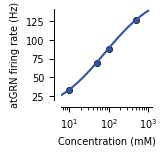

In [24]:
# Hill function of atGRN 
c_exp = [10,50,100,500]
c1_range = np.logspace(0, 3, 200)
c2_range = np.zeros(len(c1_range))
c_all = np.transpose(np.vstack([c1_range,c2_range]))
f_c1 = hill(c1_range,V_at,K_at,n_at)
f_c2 = hill(c2_range,V_tp,K_tp,n_tp)
f_c1_exp = hill(c_exp,V_at,K_at,n_at)
f_c2_exp = hill([0,0,0,0],V_tp,K_tp,n_tp)
f_c = np.transpose(np.vstack([f_c1,f_c2]))
f_c_exp = np.transpose(np.vstack([f_c1_exp,f_c2_exp]))

r_val = interp_func_tarsal(f_c)
r_val_geo = interp_func_geo_tarsal(f_c)


# ---- 조건 선택 ----



cond = 0   # 0=suc, 1=geo
cond_arr = np.zeros(len(c_all))
per_pred = model_prediction_global(params_opt_tarsal.x, c_all , cond_arr,interp_func_tarsal,interp_func_geo_tarsal)



cond = 1   # 0=suc, 1=geo
cond_arr = np.ones(len(c_all))
per_pred_geo = model_prediction_global(params_opt_tarsal.x, c_all, cond_arr, interp_func_tarsal,interp_func_geo_tarsal)


fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))

ax.semilogx(c1_range, f_c1,color=atGRN_color)
ax.scatter(c_exp,f_c1_exp,color=atGRN_color,s=ms,edgecolor='black',linewidths=.5) #,marker='^'

ax.set_xlim((6.237348354824193, 1273.5030810166616))
# ax.set_yticks([0,50,100,150])
ax.set_ylim(atGRN_ylim)
ax.set_xlabel("Concentration (mM)")
ax.set_ylabel("atGRN firing rate (Hz)")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)
ax.set_yticks(atGRN_yrange)
ylim = ax.get_ylim()
# plt.savefig('figures_method/hill_atGRN.svg')

(57.14339390685963, 101.88099028295954)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

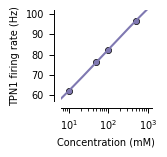

In [38]:
c_exp = [10,50,100,500]
c2_range = np.logspace(0, 3, 200)
c1_range = np.zeros(len(c1_range))
c_all = np.transpose(np.vstack([c1_range,c2_range]))
f_c1 = hill(c1_range,V_at,K_at,n_at)
f_c2 = hill(c2_range,V_tp,K_tp,n_tp)
f_c1_exp = hill([0,0,0,0],V_at,K_at,n_at)
f_c2_exp = hill(c_exp,V_tp,K_tp,n_tp)
f_c = np.transpose(np.vstack([f_c1,f_c2]))
f_c_exp = np.transpose(np.vstack([f_c1_exp,f_c2_exp]))

r_val = interp_func_tarsal(f_c)
r_val_geo = interp_func_geo_tarsal(f_c)


# ---- 조건 선택 ----



cond = 0   # 0=suc, 1=geo
cond_arr = np.zeros(len(c_all))
per_pred = model_prediction_global(params_opt_tarsal.x, c_all , cond_arr,interp_func_tarsal,interp_func_geo_tarsal)



cond = 1   # 0=suc, 1=geo
cond_arr = np.ones(len(c_all))
per_pred_geo = model_prediction_global(params_opt_tarsal.x, c_all, cond_arr,interp_func_tarsal,interp_func_geo_tarsal)


fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))

ax.semilogx(c2_range, f_c2,color=TPN1_color)
ax.scatter(c_exp,f_c2_exp,color=TPN1_color,s=ms,edgecolor='black',linewidths=.5) # ,marker='v'

ax.set_xlim((6.237348354824193, 1273.5030810166616))
ax.set_yticks([0,50,100,150])
ax.set_xlabel("Concentration (mM)")
ax.set_ylabel("TPN1 firing rate (Hz)")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)
ax.set_yticks(TPN1_yrange)
ax.set_ylim(TPN1_ylim)

# plt.savefig('figures_method/hill_TPN1.svg')

(57.14339390685963, 101.88099028295954)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

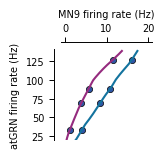

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

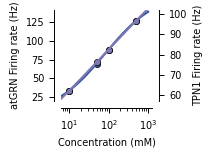

In [41]:
atGRN_mn9 = interp_func_tarsal(f_c_exp)
atGRN_geo_mn9 = interp_func_geo_tarsal(f_c_exp)

fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))
ax.plot(r_val,f_c1,suc_color)
ax.plot(r_val_geo,f_c1,geo_color)
ax.scatter(interp_func_tarsal(f_c_exp),f_c1_exp,color=atGRN_color,s=ms,edgecolor='black',linewidths=.5) # ,marker='^'
ax.scatter(interp_func_geo_tarsal(f_c_exp),f_c1_exp,color=atGRN_color,s=ms,edgecolor='black',linewidths=.5) # ,marker='^'


ax.set_yticks(atGRN_yrange)
ax.set_ylim(atGRN_ylim)
ax.set_ylabel("atGRN firing rate (Hz)")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)
ax.tick_params(axis='x', bottom=False, labelbottom=False)
ax.spines['bottom'].set_visible(False)
ax.set_xlim(MN9_xlim)

secax = ax.secondary_xaxis('top')
secax.set_xlabel("MN9 firing rate (Hz)")
secax.tick_params(width=.7)
secax.spines["top"].set_linewidth(.7)
secax.spines["top"].set_position(("outward", 5))
secax.set_xticks(MN9_xrange)
secax.set_xlim(MN9_xlim)
# plt.savefig('figures_method/simul_atGRN.svg')

c_exp = [10,50,100,500]
c2_range = np.logspace(0, 3, 200)
c1_range = np.logspace(0, 3, 200)
c_all = np.transpose(np.vstack([c1_range,c2_range]))
f_c1 = hill(c1_range,V_at,K_at,n_at)
f_c2 = hill(c2_range,V_tp,K_tp,n_tp)
f_c1_exp = hill(c_exp,V_at,K_at,n_at)
f_c2_exp = hill(c_exp,V_tp,K_tp,n_tp)
f_c = np.transpose(np.vstack([f_c1,f_c2]))
f_c_exp = np.transpose(np.vstack([f_c1_exp,f_c2_exp]))
r_val = interp_func_tarsal(f_c)
r_val_geo = interp_func_geo_tarsal(f_c)


# ---- 조건 선택 ----



cond = 0   # 0=suc, 1=geo
cond_arr = np.zeros(len(c_all))
per_pred = model_prediction_global(params_opt_tarsal.x, c_all , cond_arr,interp_func_tarsal,interp_func_geo_tarsal)



cond = 1   # 0=suc, 1=geo
cond_arr = np.ones(len(c_all))
per_pred_geo = model_prediction_global(params_opt_tarsal.x, c_all, cond_arr,interp_func_tarsal,interp_func_geo_tarsal)


fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))

# atGRN Curve 
ax.semilogx(c1_range, f_c1,color=atGRN_color)
ax.scatter(c_exp,f_c1_exp,color=atGRN_color,edgecolor='black',linewidths=.5,s=ms)
ax.set_xlim((6.237348354824193, 1273.5030810166616))
ax.set_yticks(atGRN_yrange)
ax.set_ylim(atGRN_ylim)
ax.set_xlabel("Concentration (mM)")
ax.set_ylabel("atGRN Firing rate (Hz)")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)


# TPN1 curve 
secyax = ax.twinx()
secyax.set_xlim((6.237348354824193, 1273.5030810166616))
secyax.semilogx(c2_range, f_c2,color=TPN1_color)
secyax.scatter(c_exp,f_c2_exp,color=TPN1_color,edgecolor='black',linewidths=.5,s=ms)
secyax.set_xlabel("Concentration (mM)")
secyax.set_ylabel("TPN1 Firing rate (Hz)")
secyax.spines[["left", "top",'bottom']].set_visible(False)
secyax.spines["right"].set_position(("outward", 5))

secyax.spines[["right"]].set_linewidth(.7)
secyax.tick_params(axis="both", width=.7)
secyax.set_yticks(TPN1_yrange)

secyax.set_ylim(TPN1_ylim)

# Simulation result - stimulating GRNs

(-1.0, 21.0)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

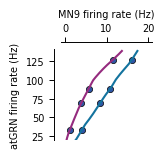

In [42]:
atGRN_mn9 = interp_func_tarsal(f_c_exp)
atGRN_geo_mn9 = interp_func_geo_tarsal(f_c_exp)

fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))
ax.plot(r_val,f_c1,suc_color)
ax.plot(r_val_geo,f_c1,geo_color)
ax.scatter(interp_func_tarsal(f_c_exp),f_c1_exp,color=atGRN_color,s=ms,edgecolor='black',linewidths=.5) # ,marker='^'
ax.scatter(interp_func_geo_tarsal(f_c_exp),f_c1_exp,color=atGRN_color,s=ms,edgecolor='black',linewidths=.5) # ,marker='^'


ax.set_yticks(atGRN_yrange)
ax.set_ylim(atGRN_ylim)
ax.set_ylabel("atGRN firing rate (Hz)")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)
ax.tick_params(axis='x', bottom=False, labelbottom=False)
ax.spines['bottom'].set_visible(False)
ax.set_xlim(MN9_xlim)

secax = ax.secondary_xaxis('top')
secax.set_xlabel("MN9 firing rate (Hz)")
secax.tick_params(width=.7)
secax.spines["top"].set_linewidth(.7)
secax.spines["top"].set_position(("outward", 5))
secax.set_xticks(MN9_xrange)
secax.set_xlim(MN9_xlim)
# plt.savefig('figures_method/simul_atGRN.svg')



(-1.0, 21.0)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

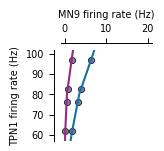

In [39]:
TPN1_mn9 = interp_func_tarsal(f_c_exp)
TPN1_geo_mn9 = interp_func_geo_tarsal(f_c_exp)

fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))
ax.plot(r_val,f_c2,suc_color)
ax.plot(r_val_geo,f_c2,geo_color)
ax.scatter(interp_func_tarsal(f_c_exp),f_c2_exp,color=TPN1_color,s=ms,edgecolor='black',linewidths=.5)#,marker='v'
ax.scatter(interp_func_geo_tarsal(f_c_exp),f_c2_exp,color=TPN1_color,s=ms,edgecolor='black',linewidths=.5) #,marker='v'


ax.set_ylim(ylim)
ax.set_ylabel("TPN1 firing rate (Hz)")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)
ax.set_yticks(TPN1_yrange)
ax.set_ylim(TPN1_ylim)
ax.set_xticks(MN9_xrange)
ax.set_xlim(MN9_xlim)

ax.tick_params(axis='x', bottom=False, labelbottom=False)
ax.spines['bottom'].set_visible(False)

secax = ax.secondary_xaxis('top')
secax.set_xticks([0,5,10,15])
secax.set_xlabel("MN9 firing rate (Hz)")
secax.tick_params(width=.7)
secax.spines["top"].set_linewidth(.7)
secax.spines["top"].set_position(("outward", 5))
secax.set_xticks(MN9_xrange)
secax.set_xlim(MN9_xlim)
# plt.savefig('figures_method/simul_TPN1.svg')

(57.14339390685963, 101.88099028295954)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

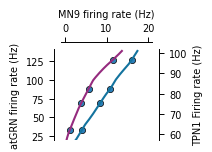

In [32]:
all_mn9 = interp_func_tarsal(f_c_exp)
all_geo_mn9 = interp_func_geo_tarsal(f_c_exp)

fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))
ax.plot(r_val,f_c1,suc_color)
ax.plot(r_val_geo,f_c1,geo_color)
ax.scatter(interp_func_tarsal(f_c_exp),f_c1_exp,color=tarsal_color,s=ms,edgecolor='black',linewidths=.5)#,marker='v'
ax.scatter(interp_func_geo_tarsal(f_c_exp),f_c1_exp,color=tarsal_color,s=ms,edgecolor='black',linewidths=.5) #,marker='v'


ax.set_yticks(atGRN_yrange)
ax.set_ylim(atGRN_ylim)
ax.set_ylabel("atGRN firing rate (Hz)")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)
ax.set_xticks(MN9_xrange)
ax.set_xlim(MN9_xlim)

ax.tick_params(axis='x', bottom=False, labelbottom=False)
ax.spines['bottom'].set_visible(False)

secax = ax.secondary_xaxis('top')
secax.set_xticks([0,5,10,15])
secax.set_xlabel("MN9 firing rate (Hz)")
secax.tick_params(width=.7)
secax.spines["top"].set_linewidth(.7)
secax.spines["top"].set_position(("outward", 5))
secax.set_xticks(MN9_xrange)
secax.set_xlim(MN9_xlim)


secyax = ax.twinx()
# secyax.set_xlim((6.237348354824193, 1273.5030810166616))
secyax.set_xlabel("Concentration (mM)")
secyax.set_ylabel("TPN1 Firing rate (Hz)")
secyax.spines[["left", "top",'bottom']].set_visible(False)
secyax.spines["right"].set_position(("outward", 5))

secyax.spines[["right"]].set_linewidth(.7)
secyax.tick_params(axis="both", width=.7)
secyax.set_yticks(TPN1_yrange)
secyax.set_ylim(TPN1_ylim)



# plt.savefig('figures_method/simul_tarsal.svg')

# Sigmoid - PER vs. MN9 firing rate  

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

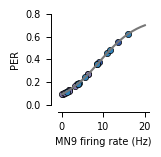

In [33]:
suc = [atGRN_mn9,TPN1_mn9,all_mn9]
geo = [atGRN_geo_mn9,TPN1_geo_mn9,all_geo_mn9]
marker = ['^','v','o']
colors = [atGRN_color,TPN1_color,tarsal_color]
popt = [k_act_T,r0_T,h_T]
fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))
x_range = list(range(0,21,1))
ax.plot(x_range,sigmoid(x_range,*popt),color='#777777')
i = 0
for s,g in zip(suc,geo):
    ax.scatter(s,sigmoid(s,*popt),s=ms,color=colors[i],edgecolors='black',linewidths=.5) #,marker=marker[i]
    ax.scatter(g,sigmoid(g,*popt),s=ms,color=colors[i],edgecolors='black',linewidths=.5)
    i+=1

ax.set_yticks(np.arange(0,1,.2))
ax.set_xlabel("MN9 firing rate (Hz)")
ax.set_ylabel("PER")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)
# ax.set_xlim([0,21])
MN9_lim = ax.get_xlim()
# plt.savefig('figures_method/activation_func.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

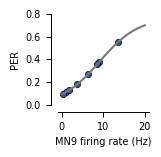

In [35]:
suc = [atGRN_mn9,TPN1_mn9,all_mn9]
geo = [atGRN_geo_mn9,TPN1_geo_mn9,all_geo_mn9]
marker = ['^','v','o']
colors = [atGRN_color,TPN1_color,tarsal_color]
popt = [k_act_T,r0_T,h_T]
fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))
x_range = list(range(0,21,1))
ax.plot(x_range,sigmoid(x_range,*popt),color='#777777')
i = 0
s = suc[i]
g = geo[i]
ax.scatter(s,sigmoid(s,*popt),s=ms,color=colors[i],edgecolors='black',linewidths=.5) #,marker=marker[i]
ax.scatter(g,sigmoid(g,*popt),s=ms,color=colors[i],edgecolors='black',linewidths=.5)
i+=1

ax.set_yticks(np.arange(0,1,.2))
ax.set_xlabel("MN9 firing rate (Hz)")
ax.set_ylabel("PER")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)
# ax.set_xlim([0,21])
MN9_lim = ax.get_xlim()
# plt.savefig('figures_method/activation_func_1.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

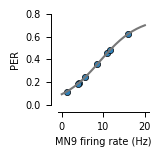

In [37]:
suc = [atGRN_mn9,TPN1_mn9,all_mn9]
geo = [atGRN_geo_mn9,TPN1_geo_mn9,all_geo_mn9]
marker = ['^','v','o']
colors = [atGRN_color,TPN1_color,tarsal_color]
popt = [k_act_T,r0_T,h_T]
fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))
x_range = list(range(0,21,1))
ax.plot(x_range,sigmoid(x_range,*popt),color='#777777')
i = 2
s = suc[i]
g = geo[i]
ax.scatter(s,sigmoid(s,*popt),s=ms,color=colors[i],edgecolors='black',linewidths=.5) #,marker=marker[i]
ax.scatter(g,sigmoid(g,*popt),s=ms,color=colors[i],edgecolors='black',linewidths=.5)
# i+=1

ax.set_yticks(np.arange(0,1,.2))
ax.set_xlabel("MN9 firing rate (Hz)")
ax.set_ylabel("PER")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)
# ax.set_xlim([0,21])
MN9_lim = ax.get_xlim()
# plt.savefig('figures_method/activation_func_2.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

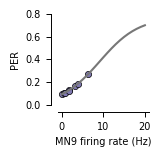

In [36]:
suc = [atGRN_mn9,TPN1_mn9,all_mn9]
geo = [atGRN_geo_mn9,TPN1_geo_mn9,all_geo_mn9]
marker = ['^','v','o']
colors = [atGRN_color,TPN1_color,tarsal_color]
popt = [k_act_T,r0_T,h_T]
fig,ax = plt.subplots(1,1,figsize=(1.18,1.18))
x_range = list(range(0,21,1))
ax.plot(x_range,sigmoid(x_range,*popt),color='#777777')
i = 1
s = suc[i]
g = geo[i]
ax.scatter(s,sigmoid(s,*popt),s=ms,color=colors[i],edgecolors='black',linewidths=.5) #,marker=marker[i]
ax.scatter(g,sigmoid(g,*popt),s=ms,color=colors[i],edgecolors='black',linewidths=.5)
# i+=1

ax.set_yticks(np.arange(0,1,.2))
ax.set_xlabel("MN9 firing rate (Hz)")
ax.set_ylabel("PER")
ax.spines[["right", "top"]].set_visible(False)
ax.spines["left"].set_position(("outward", 5))
ax.spines["bottom"].set_position(("outward", 5))
ax.spines[["bottom", "left"]].set_linewidth(.7)
ax.tick_params(axis="both", width=.7)
# ax.set_xlim([0,21])
MN9_lim = ax.get_xlim()
# plt.savefig('figures_method/activation_func_3.svg')